<a href="https://colab.research.google.com/github/manArr-dev/ml_viewers_sentiment_project/blob/main/viwer_sentiment_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
df.head()


,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [4]:
df.shape

(37249, 2)

In [5]:
df.sample()['clean_comment'].values

array(['who will get bad this time netscape kamal hasan nikki minaj netflix'],
      dtype=object)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [7]:
df.isnull().sum()

,0
clean_comment,100
category,0


In [8]:
df[df['clean_comment'].isna()]

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [9]:
df[df['clean_comment'].isna()]['category'].value_counts()

,count
category,
0,100


In [10]:
df.dropna(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(350)

In [12]:
df[df.duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df[(df['clean_comment'].str.strip() == '')]

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [16]:
df[~(df['clean_comment'].str.strip() == '')]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37244,jesus,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [17]:
df['clean_comment'] = df[
    'clean_comment'].str.lower()
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [18]:
df[df['clean_comment'].apply(lambda x : x.endswith('') or x.startswith(''))]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37244,jesus,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [19]:
url_pattern = r'http[s]://(?:[a-zA-Z]|(0-9)|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls = df[df['clean_comment'].str.contains(url_pattern, regex=True)]
comments_with_urls.head()


/tmp/ipykernel_17692/1474872293.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  comments_with_urls = df[df['clean_comment'].str.contains(url_pattern, regex=True)]


,clean_comment,category


In [20]:
comments_with_newLine = df[df['clean_comment'].str.contains('\n')]
comments_with_newLine.head()

,clean_comment,category
106,pretty sure this sarcasm satire the news 1500...,1
217,lots streams this site vietnam arsenal html\n,0
317,the govt should have only one religion says t...,0
448,what missing jpg\nand why this brilliant edit ...,1
495,you wondering whether girl will get through t...,1


In [21]:
df['clean_comment'] = df['clean_comment'].str.replace(
    '\n', '', regex=True)
df['clean_comment'] = df['clean_comment'].str.replace(
    '\r', '', regex=True)
df['clean_comment'] = df['clean_comment'].str.replace(
    '\t', '', regex=True)

In [22]:
comment_with_newLine_remaining = df[df['clean_comment'].str.contains('\r')]
comment_with_newLine_remaining.head()

,clean_comment,category


##EDA data with seaborn and pamtplotlib

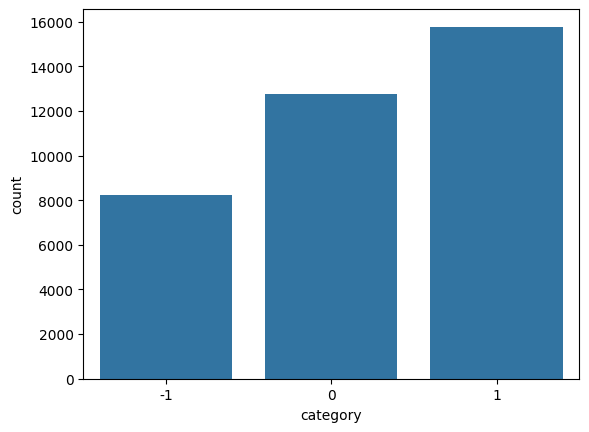

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='category', data=df)
plt.show()

##Check the frequence of distibution sentiments

In [24]:
df['category'].value_counts(normalize=True).mul(100).round(2)

,proportion
category,
1,42.86
0,34.72
-1,22.42


In [25]:
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))
df.sample(5)

,clean_comment,category,word_count
7405,naš literally means serbian lmao anyway big ca...,-1,40
21483,few things note believe brokk and sindri crea...,1,114
22290,matlab how many lakhs per month,1,6
19328,tamilnadu still vote based caste and bjp consi...,0,18
17429,just build place worship around the broken he...,1,31


In [26]:
df['word_count'].describe()


,word_count
count,36799.000000
mean,29.641512
std,56.645430
min,0.000000
25%,6.000000
50%,13.000000
75%,30.000000
max,1307.000000


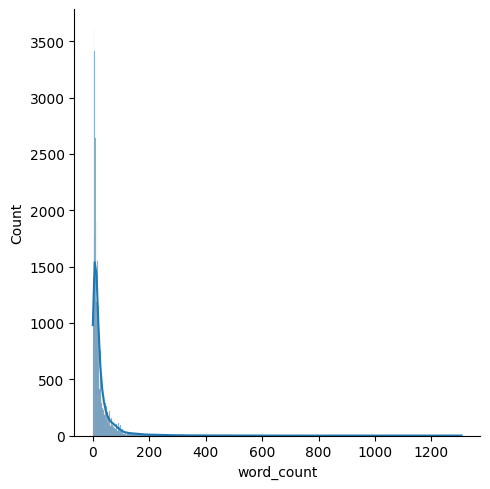

In [27]:
sns.displot(df['word_count'], kde=True)
plt.show()

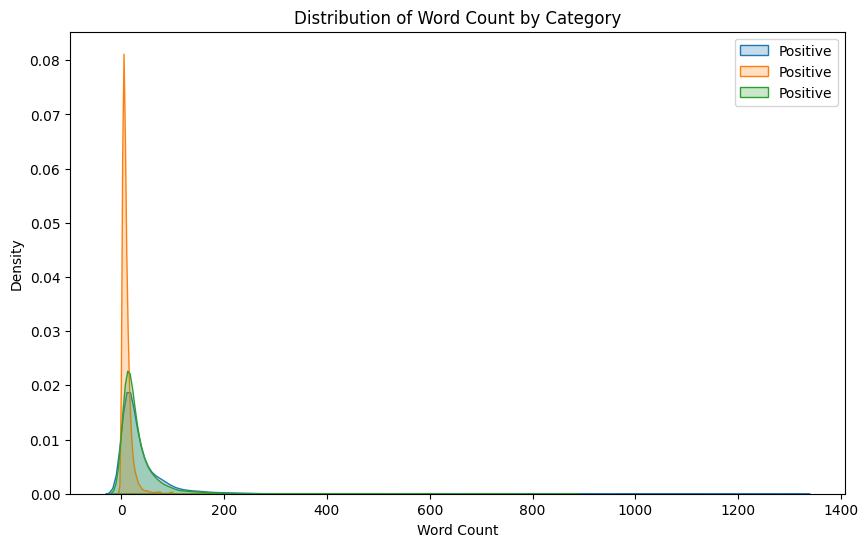

In [28]:
#create figures and axis
plt.figure(figsize=(10, 6))

#Plot KDE for category 1
sns.kdeplot(df[df['category'] == 1]['word_count'], label='Positive', fill=True)

#Plot KDE for category 0
sns.kdeplot(df[df['category'] == 0]['word_count'], label='Positive', fill=True)

#Plot KDE for category -1
sns.kdeplot(df[df['category'] == -1]['word_count'], label='Positive', fill=True)

#Adding titles and labels
plt.title('Distribution of Word Count by Category')
plt.xlabel('Word Count')
plt.ylabel('Density')

#Adding legend
plt.legend()

#Show plot
plt.show()

<Axes: ylabel='word_count'>

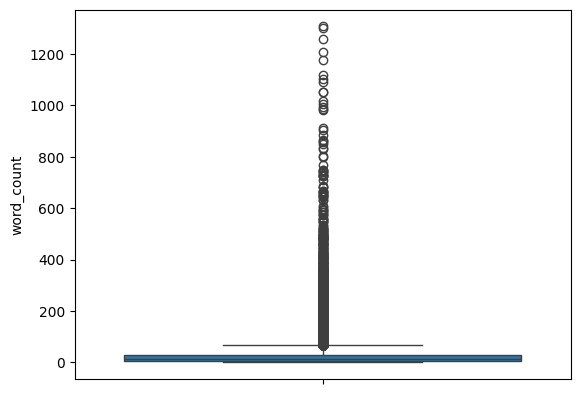

In [29]:
sns.boxplot(df['word_count'])

##Create a boxplot for 'word_count' column by category

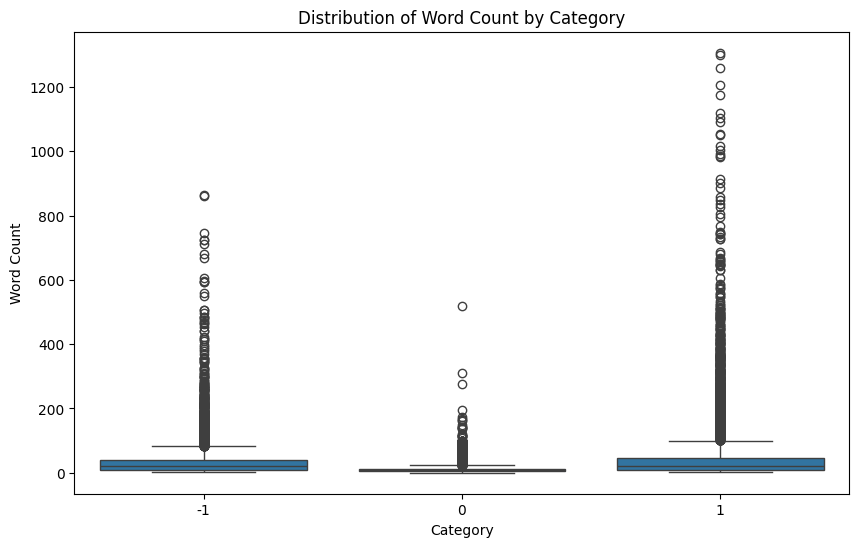

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='category', y='word_count', data=df)
plt.title('Distribution of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

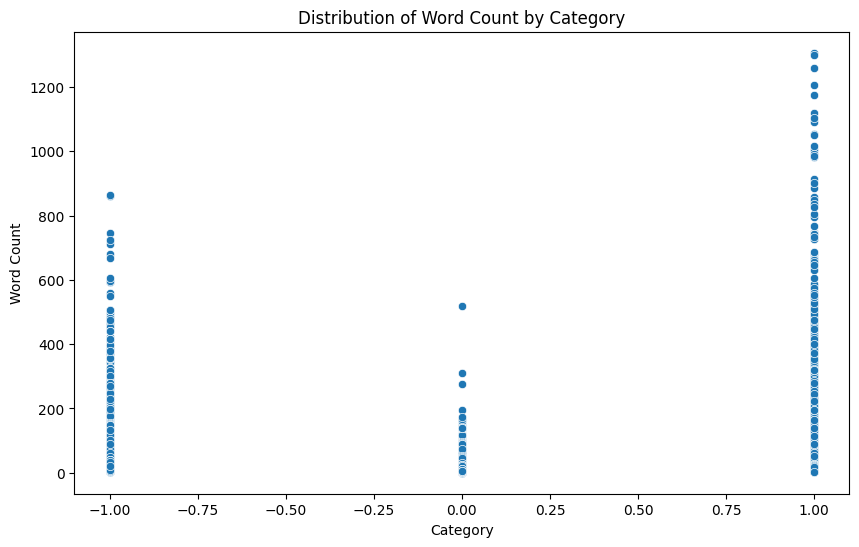

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='category', y='word_count', data=df)
plt.title('Distribution of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

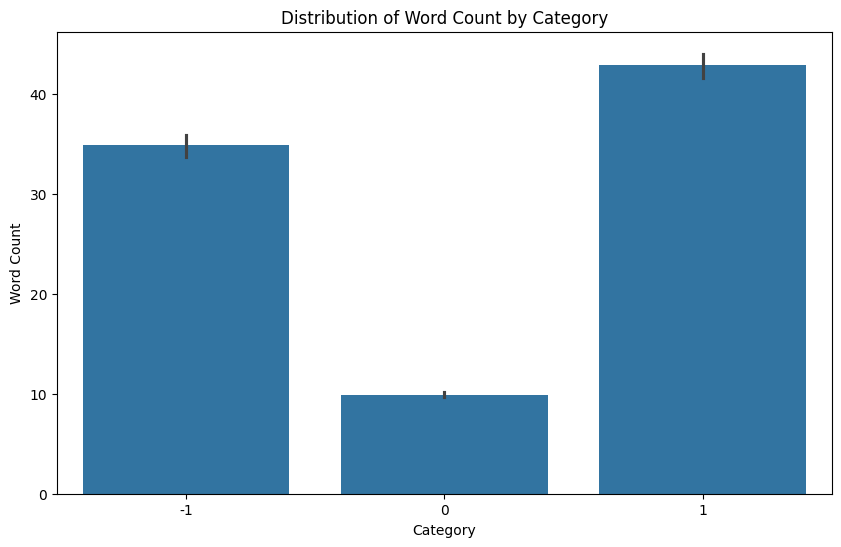

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(x='category', y='word_count', data=df)
plt.title('Distribution of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

##Performing parsing

In [33]:
!pip install nltk

In [34]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
#Define the list of english words
stop_words = set(stopwords.words('english'))
#create a new column to count the number of stop words in each comment
df['num_stop_words'] = df['clean_comment'].apply(
    lambda x: len([word for word in x.split() if word in stop_words]))
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,clean_comment,category,word_count,num_stop_words
0,family mormon have never tried explain them t...,1,39,13
1,buddhism has very much lot compatible with chr...,1,196,59
2,seriously don say thing first all they won get...,-1,86,40
3,what you have learned yours and only yours wha...,0,29,15
4,for your own benefit you may want read living ...,1,112,45


##Creating a distribution plot for num_stop_words

<Figure size 1000x600 with 0 Axes>

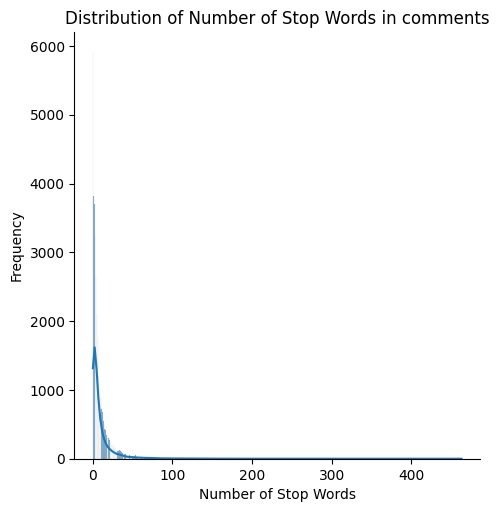

In [35]:
plt.figure(figsize=(10, 6))
sns.displot(df['num_stop_words'], kde=True)
plt.title('Distribution of Number of Stop Words in comments')
plt.xlabel('Number of Stop Words')
plt.ylabel('Frequency')
plt.show()

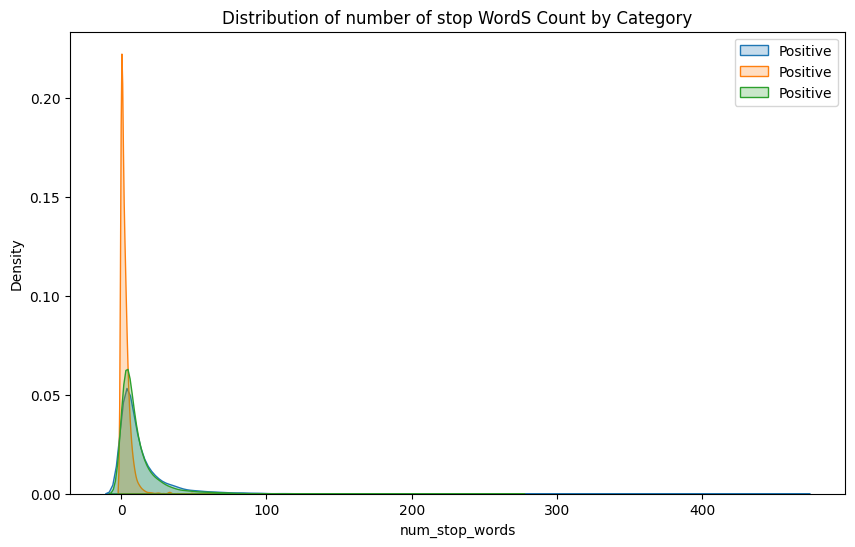

In [36]:
#create figures and axis
plt.figure(figsize=(10, 6))

#Plot KDE for category 1
sns.kdeplot(df[df['category'] == 1]['num_stop_words'], label='Positive', fill=True)

#Plot KDE for category 0
sns.kdeplot(df[df['category'] == 0]['num_stop_words'], label='Positive', fill=True)

#Plot KDE for category -1
sns.kdeplot(df[df['category'] == -1]['num_stop_words'], label='Positive', fill=True)

#Adding titles and labels
plt.title('Distribution of number of stop WordS Count by Category')
plt.xlabel('num_stop_words')
plt.ylabel('Density')

#Adding legend
plt.legend()

#Show plot
plt.show()

##Check the most used stop words in the data

/tmp/ipykernel_17692/3778168598.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')


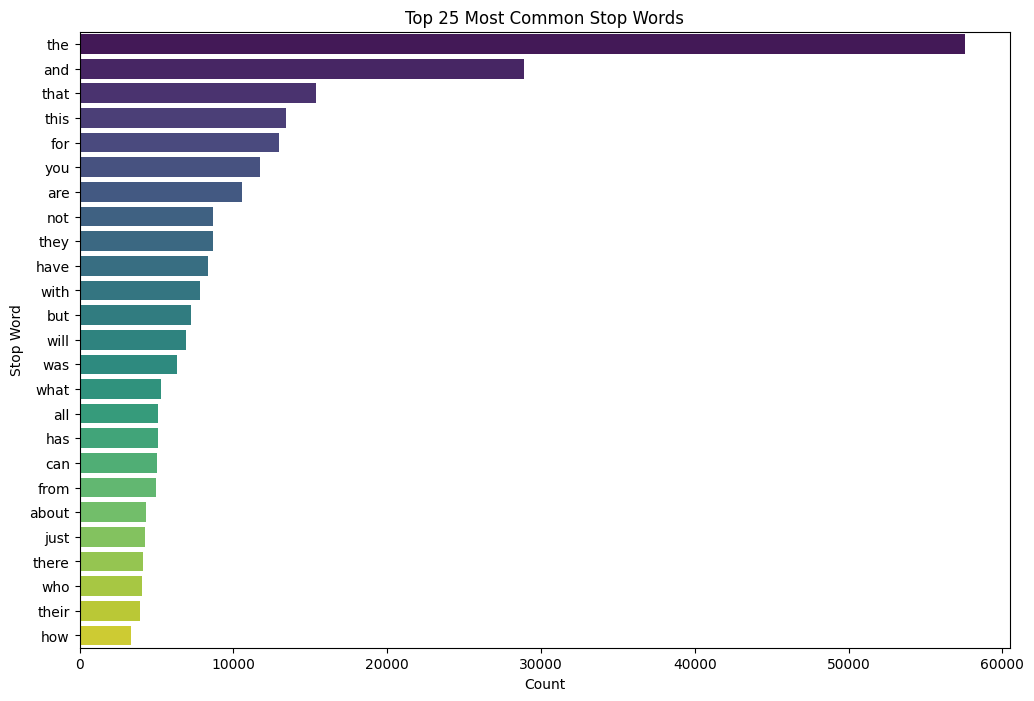

In [37]:
from collections import Counter
#Extract all stop words from previous common stop words
all_stop_words = [word for comment in df['clean_comment'] for word in comment.split() if word in stop_words]
# Count the most common stop words
most_common_stop_words = Counter(all_stop_words).most_common(25)

# Convert the most common stop words to a DataFrame for plotting
top_25_df = pd.DataFrame(most_common_stop_words, columns=['stop_word', 'count'])

# Create the barplot for the top 25 most common stop words
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')
plt.title('Top 25 Most Common Stop Words')
plt.xlabel('Count')
plt.ylabel('Stop Word')
plt.show()


In [38]:
df['num_chars'] = df['clean_comment'].apply(len)

df.head()

,clean_comment,category,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them t...,1,39,13,261
1,buddhism has very much lot compatible with chr...,1,196,59,1269
2,seriously don say thing first all they won get...,-1,86,40,460
3,what you have learned yours and only yours wha...,0,29,15,168
4,for your own benefit you may want read living ...,1,112,45,691


In [39]:
df['num_chars'].describe()


,num_chars
count,36799.000000
mean,182.959754
std,359.602666
min,0.000000
25%,39.000000
50%,81.000000
75%,185.000000
max,8665.000000


##Check how many special characters comment has

In [40]:
from collections import Counter

# Combine all comments into one large string
all_text = ' '.join(df['clean_comment'])

# Count the frequency of each character
char_frequency = Counter(all_text)

# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)



In [41]:
char_frequency_df['character'].values

array([' ', 'e', 't', ..., '婆', '妖', '醒'], dtype=object)

In [42]:
char_frequency_df.tail(50)

,character,frequency
324,ഡ,1
321,ï,1
296,淨,1
292,ण,1
1349,ూ,1
1348,ゃ,1
1347,ね,1
1346,☝,1
1345,统,1
1344,唯,1


##Check how many punctuation characters are in the comment

In [43]:
# Create a new column 'num_punctuation_chars' to count punctuation characters in each comment
df['num_punctuation_chars'] = df['clean_comment'].apply(
    lambda x: sum([1 for char in x if char in '.,!?;:"\'()[]{}-'])
)

df.sample(5)

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
18311,mann baat monthly press conference with billi...,0,21,6,133,0
30118,until started living alone parents house the ...,1,49,16,276,0
34745,finally this what required shut some naysayers...,0,23,9,154,0
28649,mamata statement days back sounded utter bulls...,1,30,11,184,0
28089,thanks crew very cool,1,4,1,22,0
